In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [7]:
df = pd.read_csv("Professional_IBM_HR_Attrition_100K (1).csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (100000, 29)


,EmployeeNumber,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,56,No,Non-Travel,Human Resources,5,2,Life Sciences,4,Male,2,3,Sales Executive,2,Single,54510,2,Yes,22,3,4,0,8,1,4,12,10,10,8
1,2,46,No,Travel_Frequently,Research & Development,19,3,Human Resources,2,Male,1,2,Research Scientist,3,Married,211604,5,No,17,3,1,3,0,5,3,25,16,14,12
2,3,32,No,Travel_Frequently,Sales,12,5,Human Resources,1,Female,2,3,Manufacturing Director,3,Divorced,111418,7,No,14,3,3,3,12,0,3,1,7,0,2
3,4,60,No,Travel_Rarely,Sales,5,3,Technical Degree,1,Male,2,3,Laboratory Technician,3,Divorced,168958,0,Yes,21,3,3,0,2,6,1,20,1,14,6
4,5,25,Yes,Travel_Rarely,Human Resources,28,4,Other,3,Male,4,5,Sales Executive,3,Divorced,121564,8,No,12,3,4,0,37,1,1,29,12,8,9


In [8]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 29 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   EmployeeNumber            100000 non-null  int64 
 1   Age                       100000 non-null  int64 
 2   Attrition                 100000 non-null  object
 3   BusinessTravel            100000 non-null  object
 4   Department                100000 non-null  object
 5   DistanceFromHome          100000 non-null  int64 
 6   Education                 100000 non-null  int64 
 7   EducationField            100000 non-null  object
 8   EnvironmentSatisfaction   100000 non-null  int64 
 9   Gender                    100000 non-null  object
 10  JobInvolvement            100000 non-null  int64 
 11  JobLevel                  100000 non-null  int64 
 12  JobRole                   100000 non-null  object
 13  JobSatisfaction           100000 non-null  int64 
 14  Marit

,0
EmployeeNumber,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EnvironmentSatisfaction,0
Gender,0


In [9]:
df.drop_duplicates(inplace=True)

print(df.isnull().sum())

print("Final Shape:", df.shape)

EmployeeNumber              0
Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64
Final Shape: (100000, 29)


In [10]:
df["SalaryBand"] = pd.cut(
    df["MonthlyIncome"],
    bins=[0, 5000, 10000, df["MonthlyIncome"].max()],
    labels=["Low", "Medium", "High"]
)

df[["MonthlyIncome", "SalaryBand"]].head()

,MonthlyIncome,SalaryBand
0,54510,High
1,211604,High
2,111418,High
3,168958,High
4,121564,High


In [11]:
df["ExperienceGroup"] = pd.cut(
    df["TotalWorkingYears"],
    bins=[-1, 5, 15, 50],
    labels=["Fresher", "Mid-Level", "Senior"]
)

df[["TotalWorkingYears", "ExperienceGroup"]].head()

,TotalWorkingYears,ExperienceGroup
0,8,Mid-Level
1,0,Fresher
2,12,Mid-Level
3,2,Fresher
4,37,Senior


In [12]:
df["RiskScore"] = (
    (df["JobSatisfaction"] <= 2).astype(int)
    + (df["WorkLifeBalance"] <= 2).astype(int)
    + (df["OverTime"] == "Yes").astype(int)
)

df["RiskCategory"] = np.where(
    df["RiskScore"] >= 2,
    "High Risk",
    "Low Risk"
)

df[["RiskScore", "RiskCategory"]].head()

,RiskScore,RiskCategory
0,2,High Risk
1,0,Low Risk
2,0,Low Risk
3,2,High Risk
4,1,Low Risk


In [13]:
total_employees = len(df)

print("Total Employees:", total_employees)

Total Employees: 100000


In [14]:
attrition_rate = (
    len(df[df["Attrition"] == "Yes"]) /
    len(df)
) * 100

print("Attrition Rate:", round(attrition_rate,2), "%")

Attrition Rate: 16.03 %


In [15]:
retention_rate = 100 - attrition_rate

print("Retention Rate:", round(retention_rate,2), "%")

Retention Rate: 83.97 %


In [16]:
avg_tenure = df["YearsAtCompany"].mean()

print("Average Tenure:", round(avg_tenure,2))
job_satisfaction = df["JobSatisfaction"].mean()

print("Job Satisfaction Score:", round(job_satisfaction,2))
avg_income = df["MonthlyIncome"].mean()

print("Average Income:", round(avg_income,2))
overtime_percentage = (
    len(df[df["OverTime"] == "Yes"])
    / len(df)
) * 100

print("Overtime Percentage:", round(overtime_percentage,2), "%")

Average Tenure: 20.01
Job Satisfaction Score: 2.5
Average Income: 132817.53
Overtime Percentage: 29.98 %


In [17]:
high_risk_count = len(
    df[df["RiskCategory"] == "High Risk"]
)

print("High Risk Employees:", high_risk_count)
kpi_df = pd.DataFrame({
    "KPI": [
        "Total Employees",
        "Attrition Rate",
        "Retention Rate",
        "Average Tenure",
        "Job Satisfaction",
        "Average Income",
        "Overtime %",
        "High Risk Employees"
    ],
    "Value": [
        total_employees,
        attrition_rate,
        retention_rate,
        avg_tenure,
        job_satisfaction,
        avg_income,
        overtime_percentage,
        high_risk_count
    ]
})

kpi_df

High Risk Employees: 40203


,KPI,Value
0,Total Employees,100000.00000
1,Attrition Rate,16.03100
2,Retention Rate,83.96900
3,Average Tenure,20.01052
4,Job Satisfaction,2.49910
5,Average Income,132817.53426
6,Overtime %,29.97600
7,High Risk Employees,40203.00000


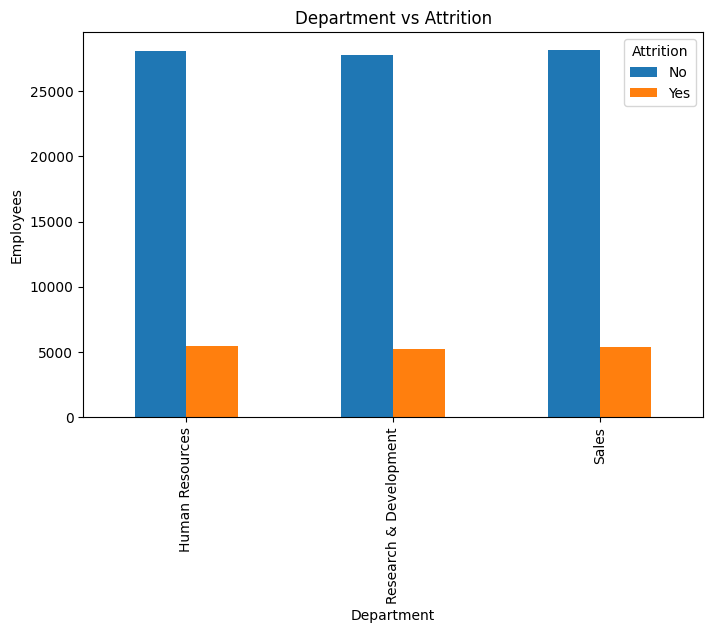

In [22]:
dept_attrition = pd.crosstab(
    df["Department"],
    df["Attrition"]
)

dept_attrition
dept_attrition.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Department vs Attrition")
plt.ylabel("Employees")
plt.show()

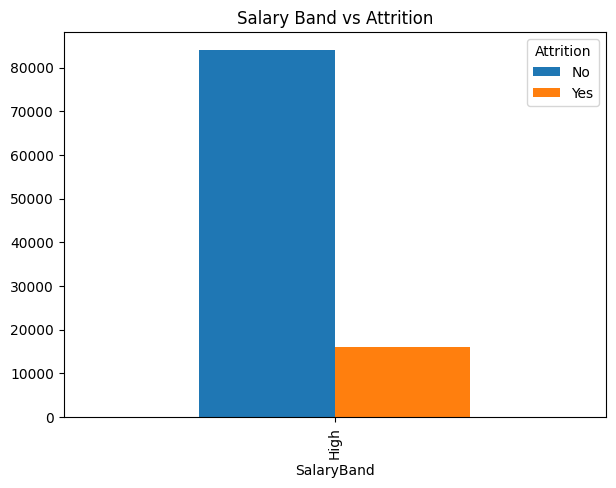

In [21]:
salary_attrition = pd.crosstab(
    df["SalaryBand"],
    df["Attrition"]
)

salary_attrition
salary_attrition.plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Salary Band vs Attrition")
plt.show()

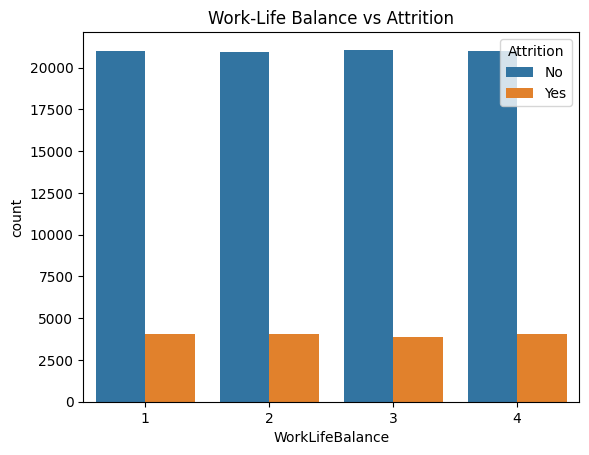

In [23]:
sns.countplot(
    data=df,
    x="WorkLifeBalance",
    hue="Attrition"
)

plt.title("Work-Life Balance vs Attrition")
plt.show()

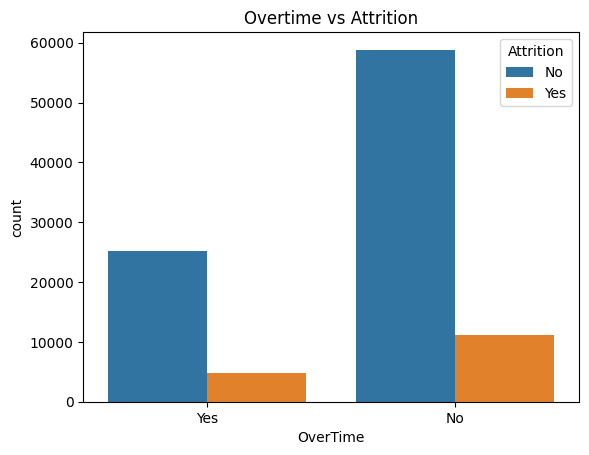

In [24]:
sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Overtime vs Attrition")
plt.show()

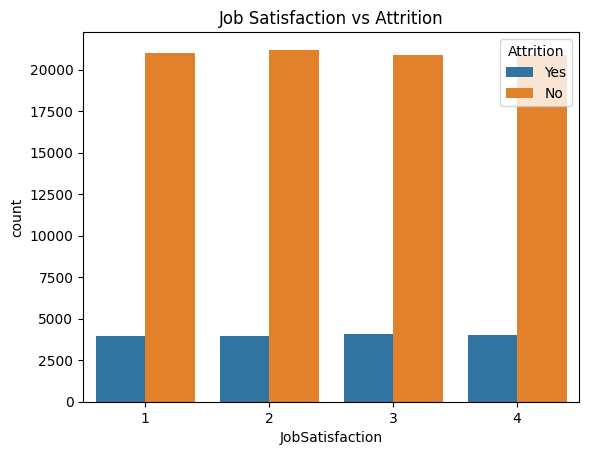

In [25]:
sns.countplot(
    data=df,
    x="JobSatisfaction",
    hue="Attrition"
)

plt.title("Job Satisfaction vs Attrition")
plt.show()

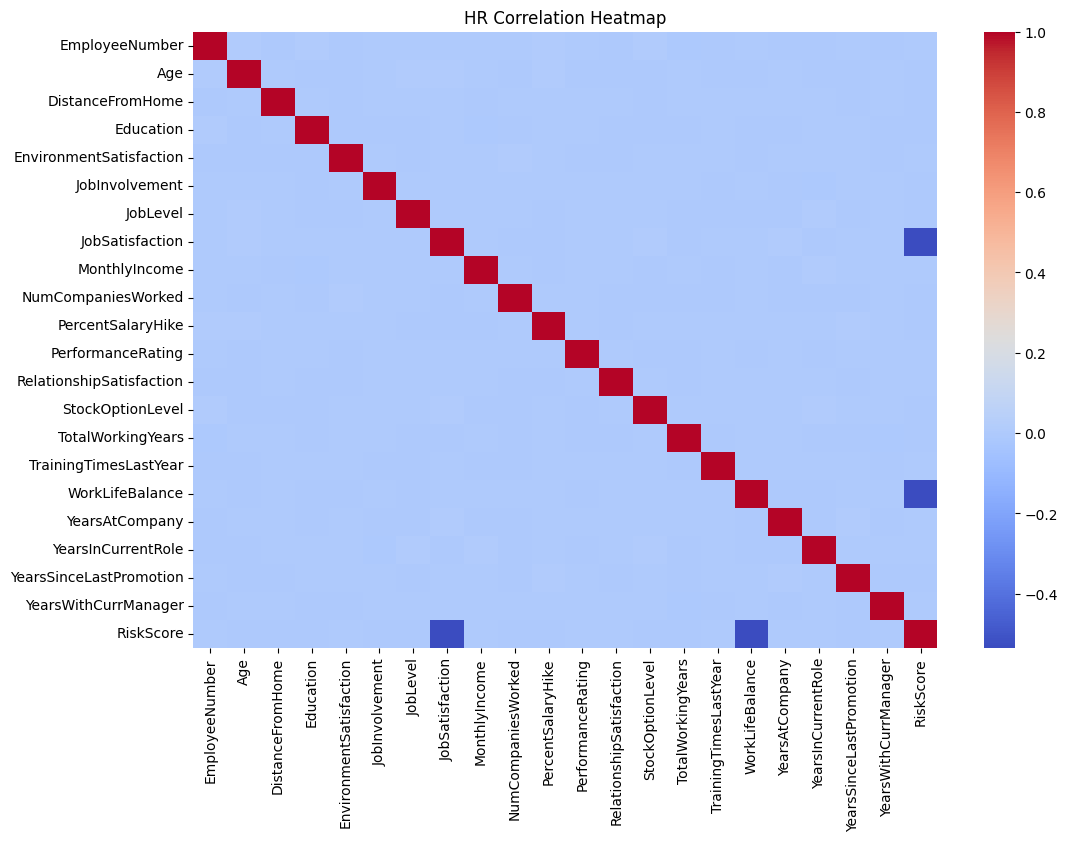

In [26]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=False,
    cmap="coolwarm"
)

plt.title("HR Correlation Heatmap")
plt.show()

In [27]:
high_risk = df[
    df["RiskCategory"] == "High Risk"
]

high_risk.head()
overtime_emp = df[
    df["OverTime"] == "Yes"
]

overtime_emp.head()
dissatisfied = df[
    df["JobSatisfaction"] <= 2
]

dissatisfied.head()
long_term = df[
    df["YearsAtCompany"] >= 10
]

long_term.head()
segment_summary = pd.DataFrame({
    "Segment":[
        "High Risk",
        "Overtime",
        "Dissatisfied",
        "Long-Term"
    ],
    "Count":[
        len(high_risk),
        len(overtime_emp),
        len(dissatisfied),
        len(long_term)
    ]
})

segment_summary

,Segment,Count
0,High Risk,40203
1,Overtime,29976
2,Dissatisfied,50076
3,Long-Term,75633


In [28]:
kpi_df.to_csv(
    "HR_KPI_Report.csv",
    index=False
)

print("KPI Report Saved")

KPI Report Saved


In [29]:
print("""
Recommendations:

1. Reduce overtime workload.
2. Improve work-life balance programs.
3. Increase engagement in high-attrition departments.
4. Monitor high-risk employees monthly.
5. Improve employee satisfaction through feedback initiatives.
""")


Recommendations:

1. Reduce overtime workload.
2. Improve work-life balance programs.
3. Increase engagement in high-attrition departments.
4. Monitor high-risk employees monthly.
5. Improve employee satisfaction through feedback initiatives.

